In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, find_peaks

import pywt
import heartpy as hp
from tqdm import tqdm

# A novel ternary pattern-based automatic psychiatric disorders classification using ECG signals

### OST: https://www.youtube.com/watch?v=uNMvABJFWHo

### Исследование: https://pmc.ncbi.nlm.nih.gov/articles/PMC10881455/

### Датасет: https://www.kaggle.com/datasets/buraktaci/Psychiatry-ECG

In [2]:
mat = loadmat(Path.cwd() / 'Psychiatry ECG' / 'Bipolar' / '1_bi (4).mat')
print(mat.keys())

print(mat['sinyal'])

dict_keys(['__header__', '__version__', '__globals__', 'label', 'sinyal'])
[[  7.8   3.1  -4.7 ...  -6.6 -13.9 -11.1]
 [  7.6   3.2  -4.4 ...  -6.4 -13.8 -11. ]
 [  6.8   2.9  -3.9 ...  -6.4 -13.7 -10.9]
 ...
 [  9.5   5.1  -4.4 ...  -3.6 -10.5  -7.8]
 [  8.5   4.7  -3.8 ...  -3.7 -10.7  -8. ]
 [  8.2   4.6  -3.6 ...  -3.8 -10.9  -8.2]]


### Класс-обёртка для нашего датасета

Оригинальный код см. в Psychiatry_ECG.py

In [3]:
def extract_number(filename):
    match = re.search(r'\((\d+)\)', str(filename)) # Напр.: supah_cool_file (4).mat
    if match:
        return int(match.group(1)) # Возвращаем найденное число как целое число
    return float('inf') # Если числа нет, ставим "бесконечность", чтобы такие файлы были в конце


class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, path):
        self.path = path
        self.classes = [f.name for f in self.path.iterdir()]

        self.samples = { cls:
            sorted((self.path / cls).iterdir(), key=extract_number) for cls in self.classes
        }
        self.pinned_disorder = None

    # Что такое k??? Типа сколько у нас файлов в этом сэмпле?
    # def get_k(self, cls): 
    #     if cls in ['Bipolar', 'Schizophrenia']:
    #         return 13
    #     elif cls == 'Depression':
    #         return 11

    def set_disorder(self, disorder):
        assert disorder in list(self.samples.keys())
        self.pinned_disorder = disorder

    def __getitem__(self, idx):
        # Получаем сигнал одного конкретного пика;
        # Изначально тут получался какой-то диапаон пиков, но...
        # Почему 11? Почему 13? Чо то K??? Сложна нипанятна!!!11
        data_raw = loadmat(self.samples[self.pinned_disorder][idx])['sinyal']

        # k = self.get_k(self.pinned_disorder)
        # idx_range = [i for i in range(idx*k, idx*k+k)]
        # data_raw = loadmat(self.samples[self.pinned_disorder][idx_range[0]])['sinyal']
        # for i in range(1, len(idx_range)):
        #     signal = loadmat(self.samples[self.pinned_disorder][idx_range[i]])['sinyal']
        #     data_raw = np.append(data_raw, signal, axis=0)

        # Теперь разобъём этот сэмпл пика на отдельные каналы ЭКГ --
        # согласно исследованию, порядок каналов в датасете стандартный
        data_res = dict()
        for ch_idx, ch_label in enumerate([
            'Lead I', 'Lead II', 'Lead III',
            'Lead aVR', 'Lead aVF', 'Lead aVL',
            'Lead v1', 'Lead v2', 'Lead v3',
            'Lead v4', 'Lead v5', 'Lead v6'
        ]):
            data_ch = data_raw[:, ch_idx]
            data_res[ch_label] = data_ch

        return data_res
    
    def __len__(self):
        # k = self.get_k(self.pinned_disorder)
        # return len(list((self.path / self.pinned_disorder).iterdir())) // k
        return len(list((self.path / self.pinned_disorder).iterdir()))
    
    def visualize(self, start, end):
        for i in range(start, end+1):
            sample = self.__getitem__(i)
            labels = list(sample.keys())

            for j in range(4*3):
                plt.subplot(4, 3, j+1)
                plt.plot(sample[labels[j]], label=f'№{i} - {labels[j]}')
                plt.grid()
                plt.legend()

        plt.show()

In [4]:
dataset = ECGDataset(Path.cwd() / 'Psychiatry ECG')

dataset

In [5]:
dataset.set_disorder('Bipolar')

dataset.classes

['Bipolar', 'Depression', 'Schizophrenia']

In [6]:
sample = dataset[6]
labels = list(sample.keys())

sample

{'Lead I': array([12.2, 12.4, 13.3, 13.5, 13.2, 13.2, 13.2, 13. , 13.1, 13.7, 14.2,
        14.1, 14. , 14.2, 14.1, 13.8, 13.9, 14.3, 14.5, 14.6, 14.7, 14.7,
        14.1, 13.4, 13.4, 13.6, 13.5, 13.6, 13.6, 12.8, 11.7, 11.3, 11.5,
        11.6, 11.7, 11.8, 11.7, 11.1, 10.8, 10.6, 10.3,  9.9,  9.5,  9.6,
         9.5,  9.2,  9.2,  9.4,  9. ,  8.2,  8.1,  8.3,  8. ,  7.9,  7.5,
         7.1,  7.6,  8.1,  7.7,  7.5,  8. ,  8.3,  8.3,  8.6,  8.9,  8.6,
         7.5,  6.7,  6.8,  7. ,  7.4,  7.6,  7.9,  8.6,  8.3,  7.4,  7.1,
         6.9,  7.1,  7.5,  7.6,  7.9,  8.4,  8.3,  7.5,  6.8,  7.1,  7.5,
         7.9,  8.3,  8.1,  7.4,  7.3,  7.5,  7.6,  7.7,  7.5,  7.5,  7.8,
         7.7,  7.3,  7.2,  7.6,  8. ,  7.9,  7.6,  7.6,  7.6,  7.9,  7.8,
         7.6,  7.5,  7.6,  7.7,  7.4,  7.2,  7.3,  7.4,  7.4,  7.5,  7.3,
         7.2,  7.6,  7.8,  7.8,  7.4,  7.2,  7.2,  6.8,  6.8,  7.2,  7.5,
         8. ,  8.4,  8.5,  8.5,  7.9,  7. ,  6.5,  6.2,  6.4,  6.4,  6.7,
         7.1,  7.1,  7.4,  7

Визуализация данных поканально

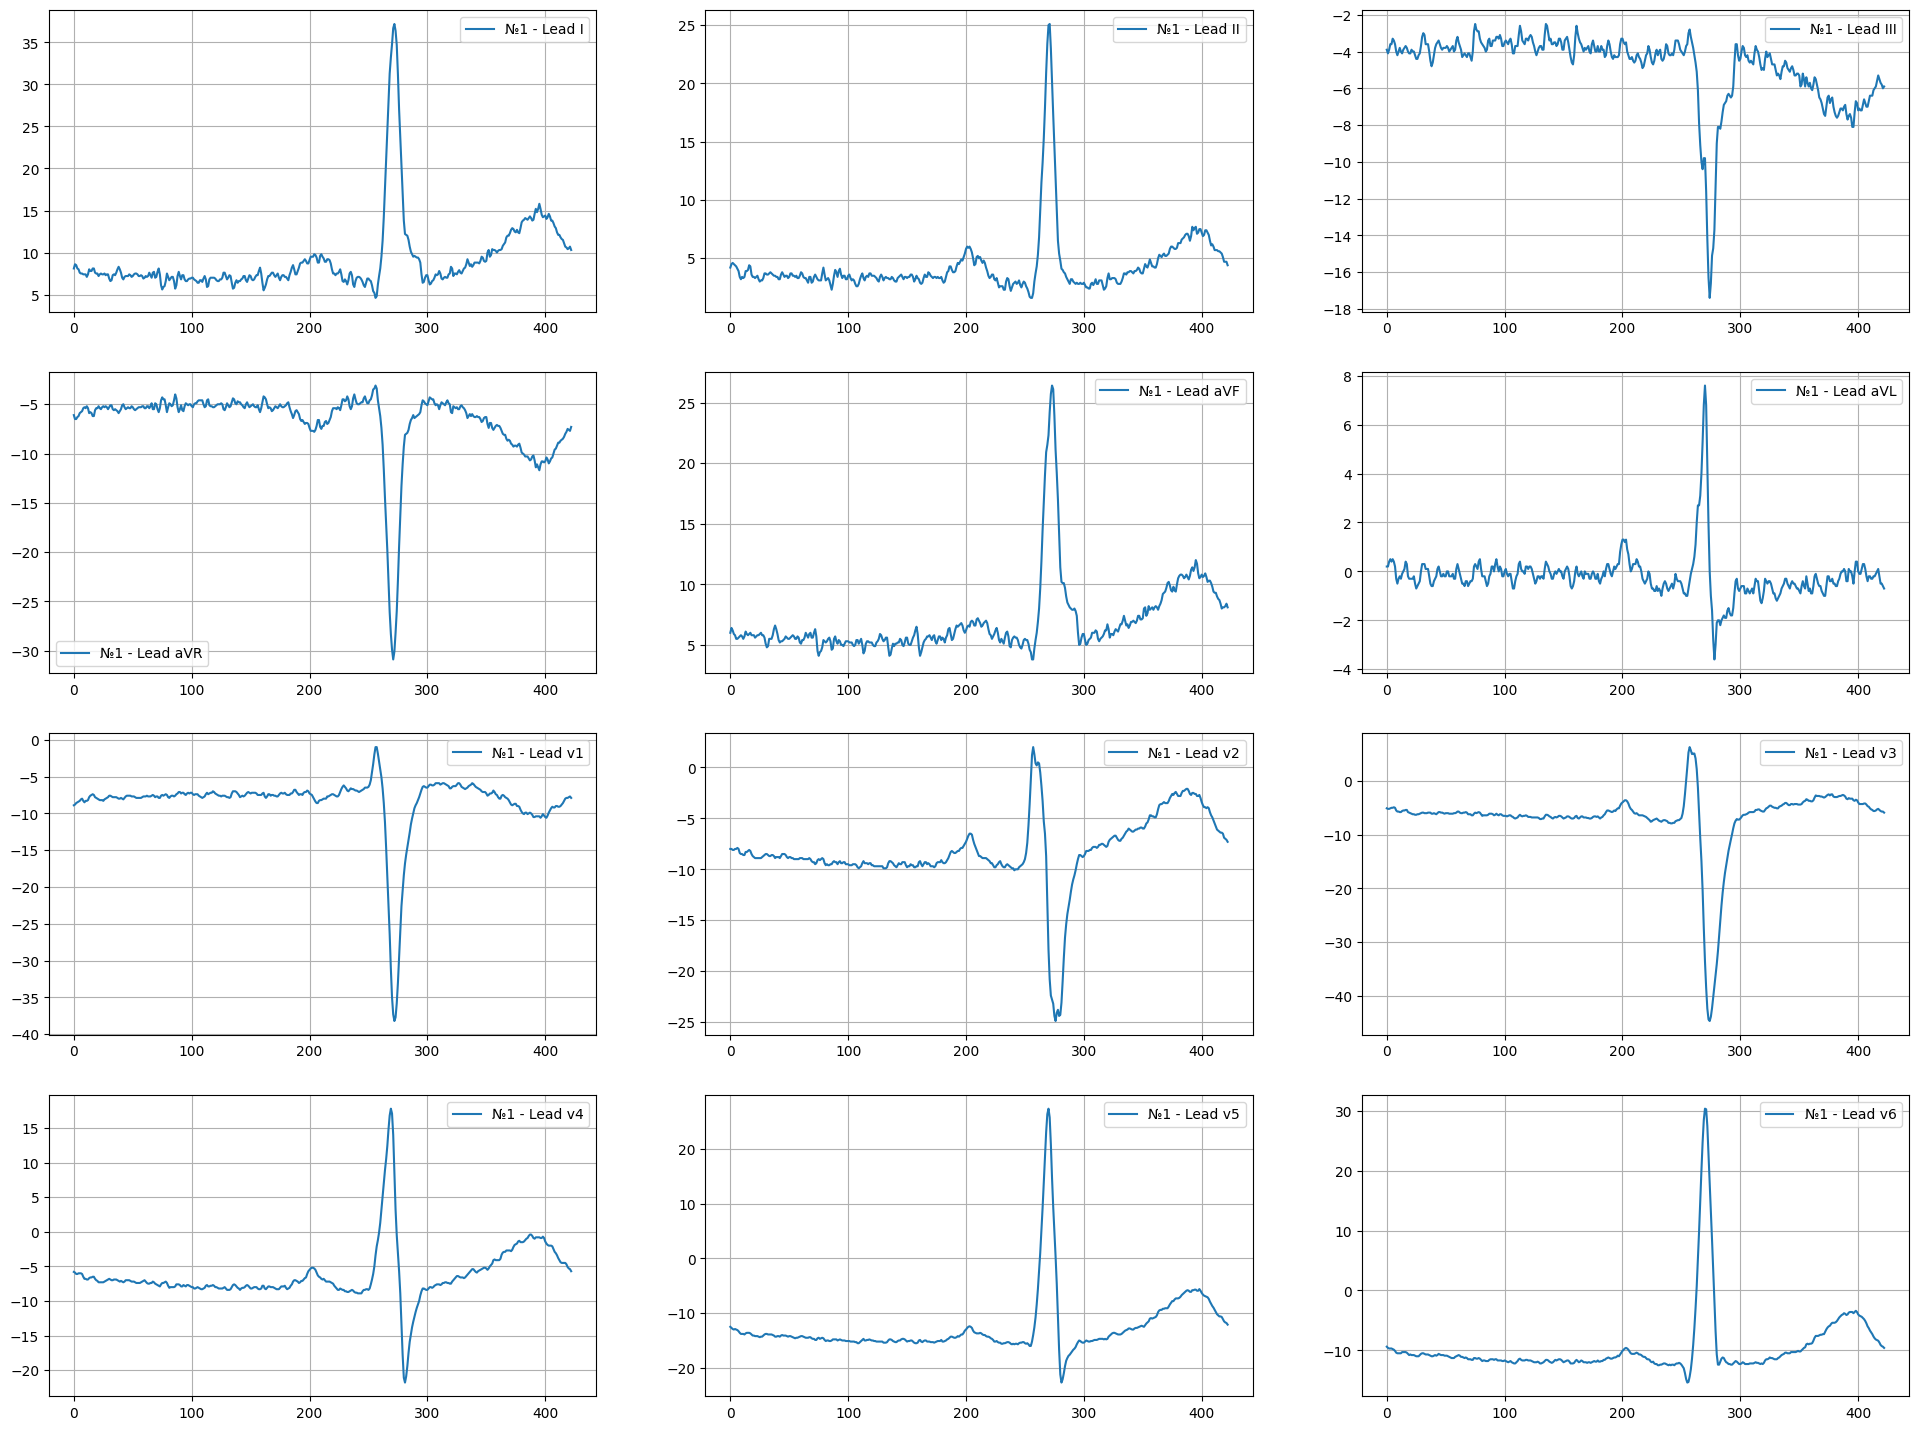

In [7]:
plt.figure(figsize=(24, 18))
dataset.visualize(1, 1)

### Обыкновенная депикизация

Как известно, весь датасет уже разделён на пики — что в принципе нам даже удобнее...

Но что, если нам для чего-то потребуется найти полные записи поцыэнта? К счастью, порядок записей после разделения на пики не был перемешан! Поэтому можно, проанализировав разрыв на краях каждого канала и выделив некоторый усреднённый порог, достаточно точно сказать, закончилась ли текущая запись или нет.

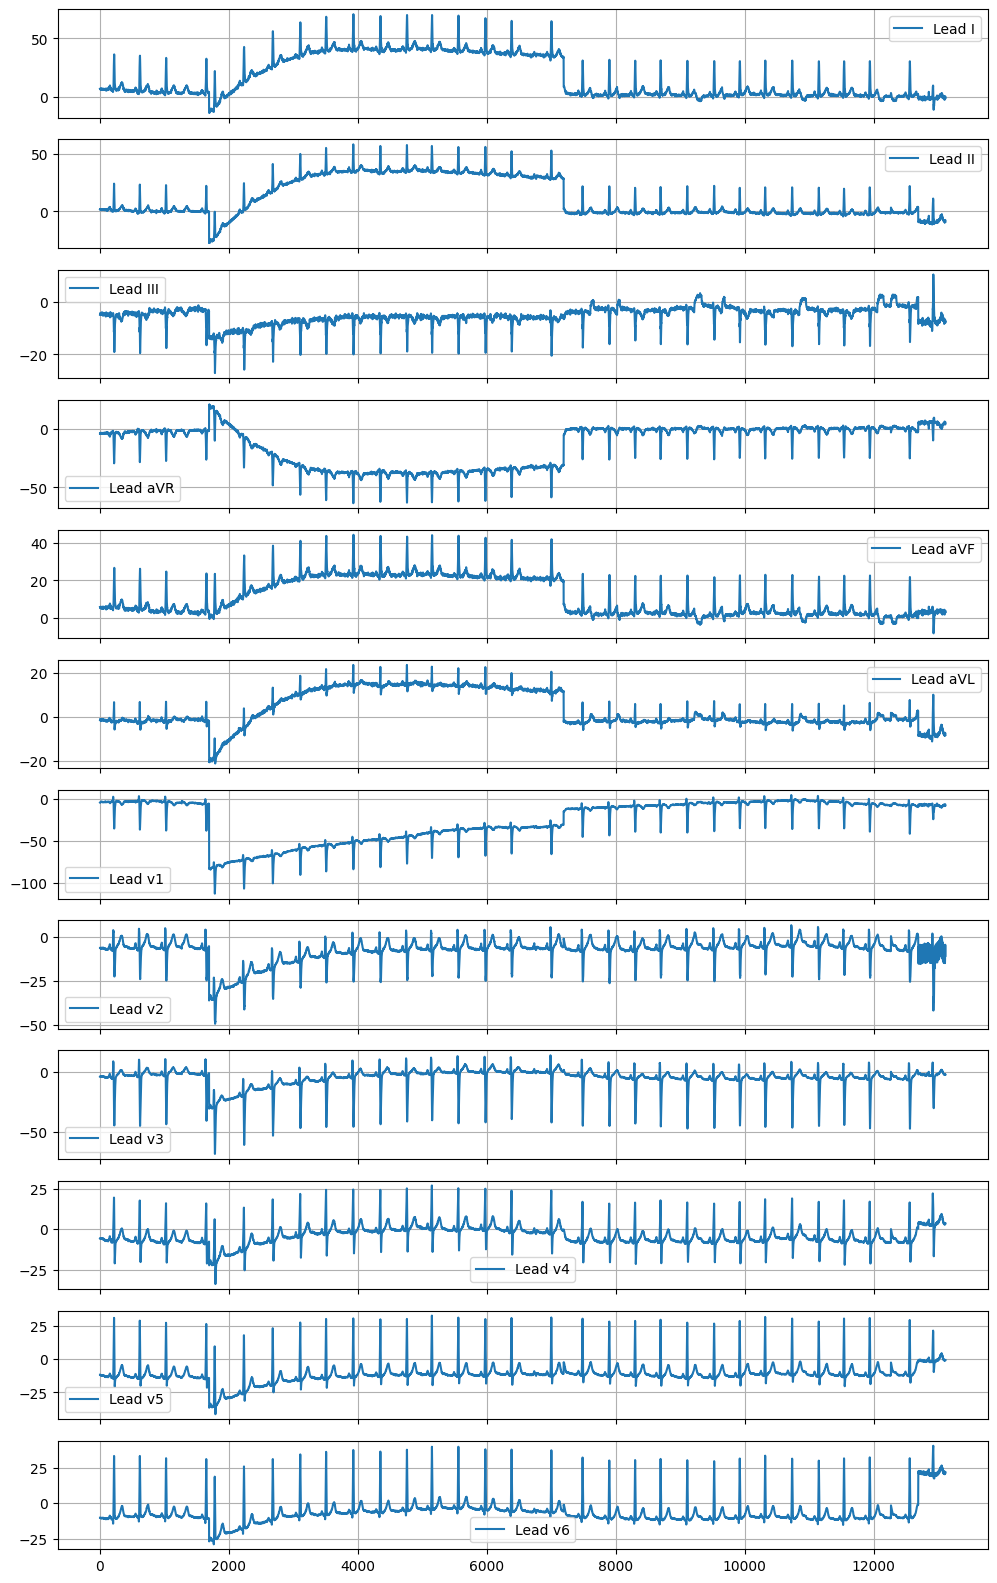

In [8]:
#Берём данные с 10 по 30 элемент
data_range_start = 10
data_range_step = 30
data_range = [dataset[i] for i in range(data_range_start, data_range_start+data_range_step+1)]

#Конкатим все отведения
data_range_concat = {
    ch: np.concatenate([sample[ch] for sample in data_range], axis=0) for ch in labels
}

fig, axes = plt.subplots(len(labels), 1, figsize=(12, 20), sharex=True)
time = np.arange(data_range_concat[labels[0]].shape[0])

for ax, ch in zip(axes, labels):
    ax.plot(time, data_range_concat[ch], label=ch)
    ax.legend()
    ax.grid()
# plt.xlim(400, 410)

plt.show()

Именно это мы сейчас и сделаем...

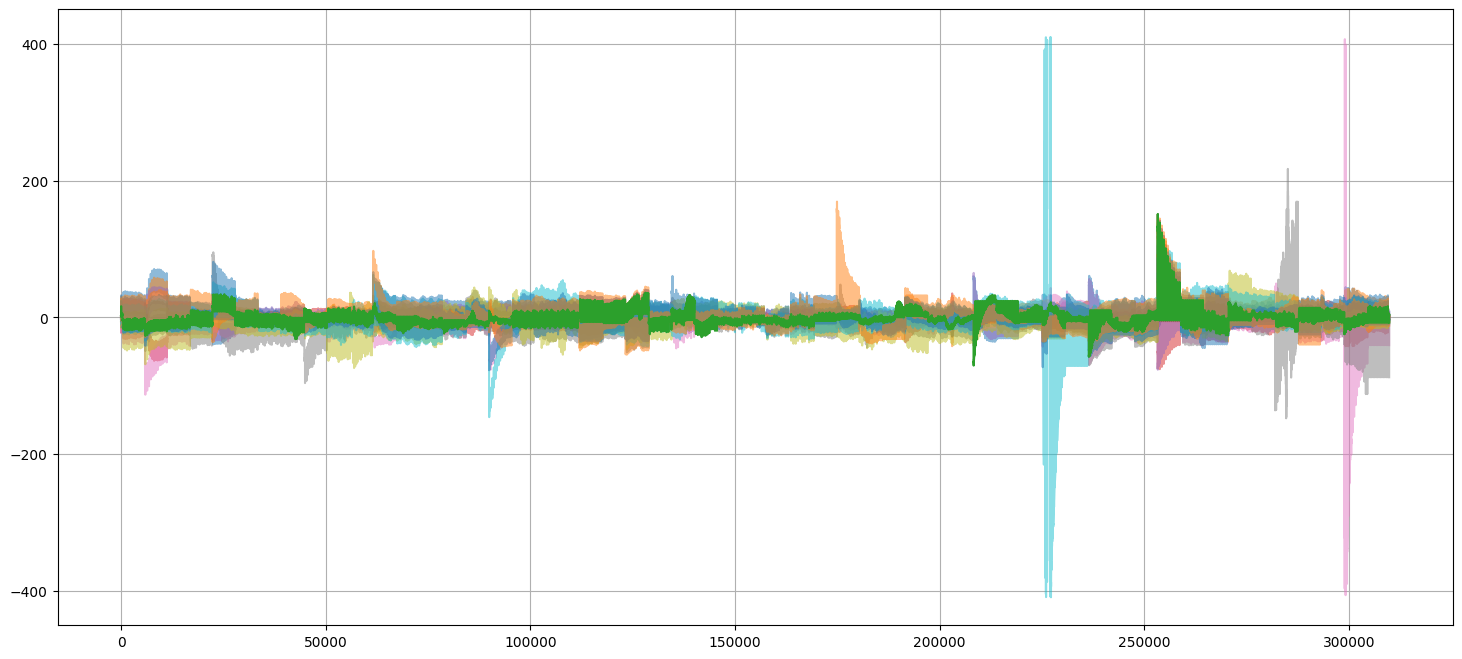

In [9]:
data = [dataset[i] for i in range(len(dataset))]

data_concat = {
    ch: np.concatenate([sample[ch] for sample in data], axis=0) for ch in labels
}


# господь_покинул_этот_мир.jpg
# ch_avg = np.sum(list([data_concat[ch] / len(labels) for ch in labels]), axis=0)

plt.figure(figsize=(18, 8))
for label in labels:
    plt.plot(data_concat[label], alpha=0.5)

plt.plot(data_concat['Lead III']) # По этому каналу лучше всего видно разрывы между записями

plt.grid()
plt.show()

Вейвлет Де Боша ~~(нет блин фильтр резни)~~ взят из preproc.ipynb

In [10]:
def denoise_ppg(ppg_signal, wavelet='db2', level=2, threshold_factor=1.5):
    coeffs = pywt.wavedec(ppg_signal, wavelet, level=level)

    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_factor * sigma

    coeffs_thresholded = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]

    denoised_signal = pywt.waverec(coeffs_thresholded, wavelet)
    denoised_signal = denoised_signal[:len(ppg_signal)]

    return denoised_signal

data_filtered = [
    { label: denoise_ppg(data[i][label], 'db5', 10, 5) for label in labels }
    for i in range(len(dataset))
]

data_filtered_concat = {
    ch: np.concatenate([sample[ch] for sample in data_filtered], axis=0) for ch in labels
}


deltas_threshold = 3.0  

rec_slices = [
    slice(-9999, 0) # Временное значение, чтобы не было ошибки
]

for i in range(len(dataset) - 1):
    deltas_mean = 0

    for label in labels:
        delta = np.abs(
            np.median(np.abs(data_filtered[i][label])) - np.median(np.abs(data_filtered[i+1][label]))
            # data[i][label][-1] - data[i+1][label][0]
        )
        deltas_mean += delta / len(labels)
    print(f'Средняя дельта между №{i} и №{i+1} -- {deltas_mean}')

    if (deltas_mean > deltas_threshold) or (i == len(dataset) - 2):
        rec_slices.append(
            slice(rec_slices[-1].stop, i+2)
        )

rec_slices.pop(0) # Удаляем временное значение

print('\nПредположительные отрезки записей: ' + str(rec_slices))

C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 10 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Средняя дельта между №0 и №1 -- 4.381330069951121
Средняя дельта между №1 и №2 -- 0.7208319123738751
Средняя дельта между №2 и №3 -- 0.6577914100687895
Средняя дельта между №3 и №4 -- 0.4422269867486706
Средняя дельта между №4 и №5 -- 0.5315514887734564
Средняя дельта между №5 и №6 -- 0.3726928213205356
Средняя дельта между №6 и №7 -- 0.7658933980847333
Средняя дельта между №7 и №8 -- 0.3931183628565888
Средняя дельта между №8 и №9 -- 0.5536850460347486
Средняя дельта между №9 и №10 -- 0.46588542953188133
Средняя дельта между №10 и №11 -- 0.8863835304635244
Средняя дельта между №11 и №12 -- 0.6680795058644532
Средняя дельта между №12 и №13 -- 0.24312774208670124
Средняя дельта между №13 и №14 -- 16.131984369710757
Средняя дельта между №14 и №15 -- 7.567200821222008
Средняя дельта между №15 и №16 -- 6.43803261182404
Средняя дельта между №16 и №17 -- 4.407720110238149
Средняя дельта между №17 и №18 -- 2.156786162470245
Средняя дельта между №18 и №19 -- 1.305068067336246
Средняя дельта ме

Посмотрим, что получилось... нутакое

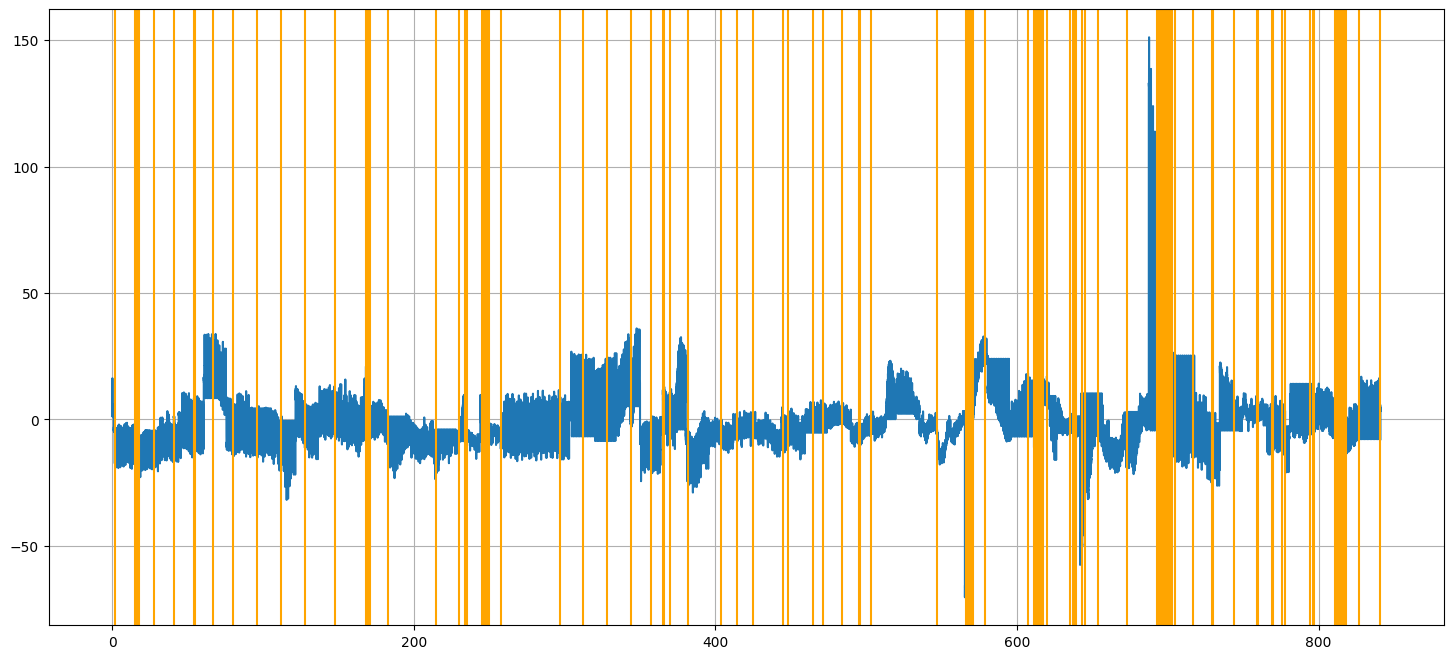

In [11]:
plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead III'])), data_concat['Lead III'])

for rs in rec_slices:
    plt.axvline(rs.stop, color='orange')

plt.grid()
plt.show()

В отчании я решил попробовать разбить сигналы константами, чтобы возможно увидеть какие-то взаимосвязи… и обаружил, что длины каждой из записей в полностью сконкатенированном датасете равны, просто имеют немноого разные смещение и длину в зависимости от типа расстройства!!

Абсолютно верного значения, конечно же, не существует, но для устранения всех погрешностей достаточно вырезать все те пики, на которые приходится разделение записи.

54.17754098360656


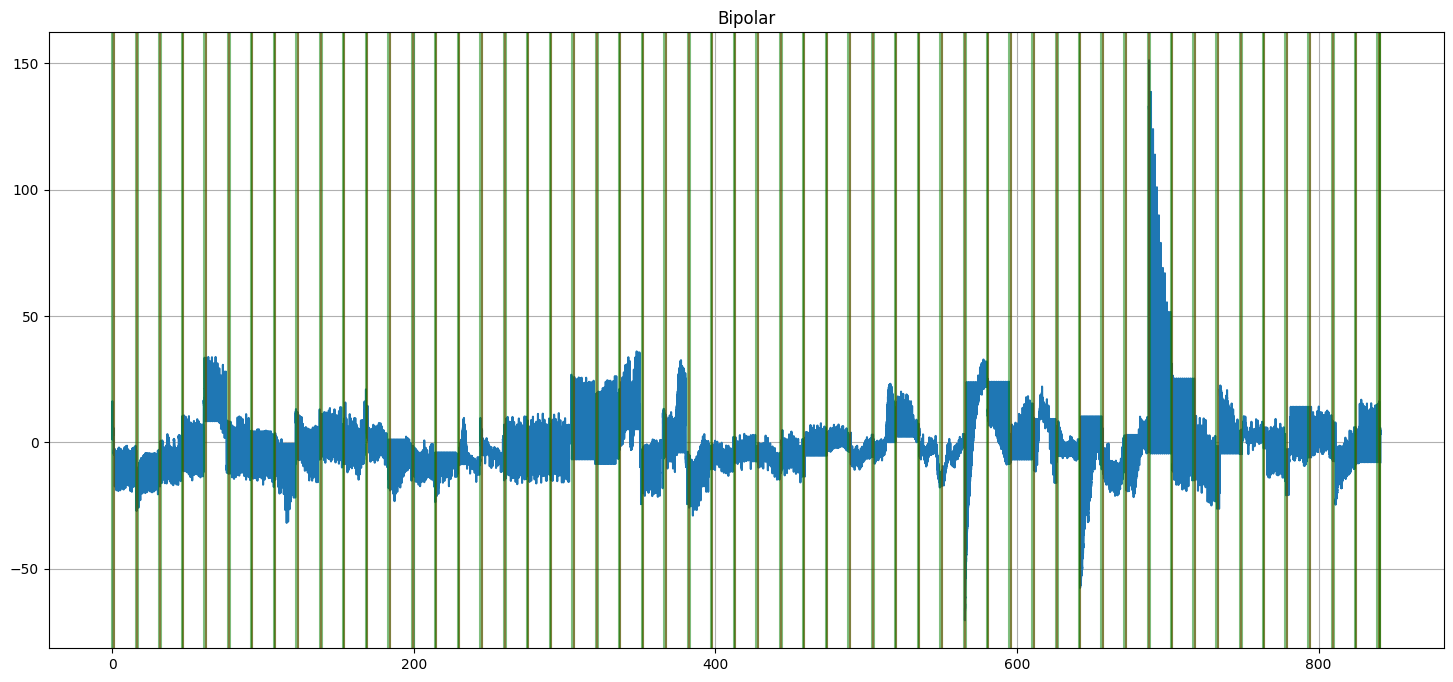

In [12]:
podbor = []


if dataset.pinned_disorder == 'Depression':
    print(len(dataset) / 14.49 - 0.79)
    podbor.append(0.79)
elif dataset.pinned_disorder == 'Schizophrenia':
    print(len(dataset) / 14.263 - 12.461)
    # podbor.append(12.461)
elif dataset.pinned_disorder == 'Bipolar':
    print(len(dataset) / 15.25 - 0.97)
    podbor.append(0.97)

while podbor[-1] < len(dataset):
    if dataset.pinned_disorder == 'Depression':
        podbor.append(podbor[-1] + 14.45)
    elif dataset.pinned_disorder == 'Schizophrenia':
        podbor.append(podbor[-1] + 14.263)
    elif dataset.pinned_disorder == 'Bipolar':
        podbor.append(podbor[-1] + 15.25)

# Исправляем последний пик, чтобы в slice он лежал ровно на конце данных
podbor[-1] = float(np.floor(len(dataset)))


plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead III'])), data_concat['Lead III'])
for abobus in podbor:
    plt.axvline(abobus, color='red', alpha=0.5)
    plt.axvline(np.ceil(abobus), color='green', alpha=0.5)
    plt.axvline(np.floor(abobus), color='green', alpha=0.5)

# plt.xlim(0, 20)
plt.title(dataset.pinned_disorder)
plt.grid()
plt.show()

### Наконец, скормим наши данные в HeartPy

На это момент мой мозг потихоньку нчал плавиться, потому код тоже деградировать малясь)))

In [13]:
# b, a = butter_bandpass(0.5, 10, 256)
# filtered_signal = filtfilt(b, a, ppg_example_finger)

# wd, m = hp.process(
#     filtered_signal,
#     sample_rate=256
# )

# hp.plotter(wd, m)
# plt.show()

# for measure in m.keys():
#     print('%s: %f' %(measure, m[measure]))

In [14]:
data_slices = [slice(
        int(np.ceil(podbor[i]) / len(dataset) * len(data_concat['Lead III'])),
        int(np.floor(podbor[i+1]) / len(dataset) * len(data_concat['Lead III']))
    ) for i in range(1, len(podbor) - 1)
]

print('\nОтрезки записей в данных (с обрезанными концами): ' + str(data_slices))


Отрезки записей в данных (с обрезанными концами): [slice(6263, 11420, None), slice(11789, 16947, None), slice(17315, 22473, None), slice(22841, 28367, None), slice(28736, 33894, None), slice(34262, 39420, None), slice(39788, 44946, None), slice(45314, 50841, None), slice(51209, 56367, None), slice(56735, 61893, None), slice(62261, 67419, None), slice(67788, 73314, None), slice(73682, 78840, None), slice(79208, 84366, None), slice(84735, 89892, None), slice(90261, 95787, None), slice(96156, 101313, None), slice(101682, 106840, None), slice(107208, 112366, None), slice(112734, 118260, None), slice(118629, 123787, None), slice(124155, 129313, None), slice(129681, 134839, None), slice(135207, 140734, None), slice(141102, 146260, None), slice(146628, 151786, None), slice(152154, 157312, None), slice(157681, 163207, None), slice(163575, 168733, None), slice(169101, 174259, None), slice(174628, 179785, None), slice(180154, 185680, None), slice(186048, 191206, None), slice(191575, 196732, Non

55


C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\ma\core.py:5334: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\core\fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\core\_methods.py:206: RuntimeWarning: De

dict_keys(['hr', 'sample_rate', 'peaklist', 'ybeat', 'rolling_mean', 'RR_list', 'RR_indices', 'RR_diff', 'RR_sqdiff', 'rrsd', 'best', 'removed_beats', 'removed_beats_y', 'binary_peaklist', 'RR_masklist', 'RR_list_cor', 'nn20', 'nn50', 'poincare'])
[ 9.31330283e+00  9.01348709e+00  8.67770065e+00  8.30731957e+00
  7.90428272e+00  7.47109614e+00  7.01082898e+00  6.52710065e+00
  6.02405892e+00  5.50634905e+00  4.97907389e+00  4.44774522e+00
  3.91822674e+00  3.39666913e+00  2.88943805e+00  2.40303560e+00
  1.94401652e+00  1.51889990e+00  1.13407781e+00  7.95722005e-01
  5.09690074e-01  2.81432498e-01  1.15902039e-01  1.74669339e-02
 -1.01706197e-02  3.59507440e-02  1.57984869e-01  3.57220798e-01
  6.34036089e-01  9.87861815e-01  1.41716013e+00  1.91941519e+00
  2.49113791e+00  3.12788497e+00  3.82429221e+00  4.57412215e+00
  5.37032556e+00  6.20511623e+00  7.07005840e+00  7.95616550e+00
  8.85400931e+00  9.75383773e+00  1.06456998e+01  1.15195761e+01
  1.23655122e+01  1.31737543e+01  1.3

C:\Users\Андрей\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\heartpy\visualizeutils.py:119: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


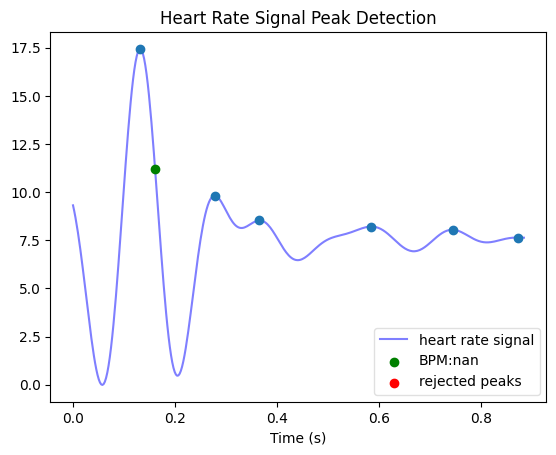

bpm: nan
ibi: nan
sdnn: nan
sdsd: nan
rmssd: nan
pnn20: nan
pnn50: nan
hr_mad: nan
sd1: nan
sd2: nan
s: nan
sd1/sd2: nan
breathingrate: nan


C:\Users\Андрей\AppData\Local\Temp\ipykernel_13700\1784727871.py:64: UserWarning: Warning: converting a masked element to nan.
  print('%s: %f' %(measure, m[measure]))


In [15]:
i = 0
data = {'hr': [], 'sdnn': [], 'peaks': []}

def butter_bandpass_filter(data, lowcut, highcut, sample_rate, order=4):
        """Встроенный фильтр Баттерворта.
        data - сигнал
        lowcut - минимально допустимая частота
        hightcut - максимально допустимая частота
        sample_rate - частота дискретизации
        order - порядок фильтра
        
        Возвращает фильтрованный сигнал"""
        nyq = 0.5 * sample_rate
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data)

print(len(data_slices))
for slc in data_slices:
    for label in labels:
        raised = True
        while raised:
            try:
                wd, m = hp.process(
                    butter_bandpass_filter(data_filtered_concat[label][slc], 4, 9, 416),
                    sample_rate=416
                )

                if not (np.isnan(m['ibi']) and np.isnan(m['sdnn'])):
                    data['hr'].append(60000/m['ibi'])
                    data['sdnn'].append(m['sdnn'])
                    data['peaks'].append([wd['peaklist']])
                    

                # hp.plotter(wd, m)

                # plt.show()

                # plt.plot(butter_bandpass_filter(data_filtered_concat[label][slc], 4, 9, 416))
                # plt.title(i)
                # # plt.xlim(0, 200)
                # plt.show()

                # i += 1

                raised = False
            except BaseException:
                if slc.stop - slc.start < 416:
                    raised = False
                    continue
                slc = slice(slc.start, slc.stop-100)

peaks, _ = find_peaks(wd['hr'])

print(wd.keys())
print(wd['hr'], wd['sample_rate'])

hp.plotter(wd, m)
plt.scatter(peaks/416, wd['hr'][peaks])
plt.show()

for measure in m.keys():
    print('%s: %f' %(measure, m[measure]))

In [16]:
wd.keys()

dict_keys(['hr', 'sample_rate', 'peaklist', 'ybeat', 'rolling_mean', 'RR_list', 'RR_indices', 'RR_diff', 'RR_sqdiff', 'rrsd', 'best', 'removed_beats', 'removed_beats_y', 'binary_peaklist', 'RR_masklist', 'RR_list_cor', 'nn20', 'nn50', 'poincare'])

In [17]:
wd['peaklist']

array([67], dtype=int64)

In [18]:
data['peaks']

[[[133, 580, 1006, 1407, 1829, 2249, 2660, 3048, 3458, 3877, 4283, 4901]],
 [[131,
   578,
   1004,
   1404,
   1826,
   2247,
   2659,
   3046,
   3456,
   3875,
   4281,
   4898,
   5074]],
 [[106,
   167,
   268,
   457,
   553,
   614,
   978,
   1040,
   1155,
   1380,
   1441,
   1455,
   1802,
   1862,
   2221,
   2282,
   2297,
   2633,
   2694,
   2709,
   2918,
   3020,
   3081,
   3191,
   3431,
   3491,
   3506,
   3849,
   3911,
   3926,
   4256,
   4317,
   4425,
   4777,
   4874,
   4935,
   4950]],
 [[101,
   549,
   974,
   1375,
   1797,
   2217,
   2629,
   3017,
   3427,
   3846,
   4252,
   4869,
   4931,
   4933]],
 [[134, 581, 1007, 1408, 1830, 2250, 2661, 3049, 3459, 3878, 4284, 4902]],
 [[123,
   571,
   998,
   1398,
   1820,
   2240,
   2654,
   3040,
   3449,
   3869,
   4275,
   4892,
   5074,
   5085]],
 [[105,
   166,
   181,
   553,
   613,
   978,
   1038,
   1379,
   1440,
   1801,
   1861,
   2221,
   2281,
   2633,
   2693,
   2708,
   3020,
   3080,